In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
from scipy.integrate import quad
import math
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# Fridge Details

In [3]:
from library.fridges import TEMP_STAGES, FRIDGE_LIBRARY
# Assuming XLD1000sl
fridge = FRIDGE_LIBRARY["XLD1000SL"]
cooling_power_budget = fridge["cooling_power"]
operating_temp = fridge["temp"]
flange_separation = fridge["lengths"]

# Thermal Conductivity

In [4]:
from library.cables import cu_thermal_conductivity

# Generate data points
temp = np.geomspace(1, 300, num=100)
values = cu_thermal_conductivity(temp)

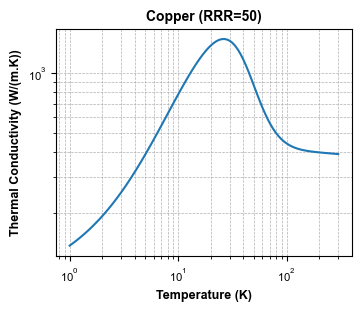

In [5]:
# Plot datapoints

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)


# Similar to graph in Fig. 5 of 2017greenConnectionRefrigerationSuperconducting (RRR=50)
ax.loglog(temp,values)
ax.set_title("Copper (RRR=50)", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel('Thermal Conductivity (W/(m.K))', fontproperties=axis_label_font)

for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.savefig(f"./cu_thermal_conductivity.png",dpi=600)
plt.show()

In [6]:
# PHL for one strand of copper
def calc_PHL(cable_length, cable_diam, T_lo, T_hi): # cable lengths in cm
    # Integrate cu_thermal_conductivity(T) from T_hi to T_lo
    result, error = quad(cu_thermal_conductivity, T_lo, T_hi)
    # Get cross sectional area of wire 
    area = np.pi * (cable_diam/2)**2
    # For 3 wires per amplifier
    return result * (area/(cable_length*1E-2)) #cable length is in cm

# Assuming AWG30 wire
cable_diam = 0.2546E-3 # m (AWG30)

print("PHL for AWG30 Copper (RRR=50)")
for temp_stage in TEMP_STAGES[1:3]:
    # get cable length
    cable_length = flange_separation[temp_stage] # cm
    
    # get operating temperatures
    current_temp_stage_idx = TEMP_STAGES.index(temp_stage)
    if current_temp_stage_idx > 0:
        prev_temp_stage = TEMP_STAGES[current_temp_stage_idx - 1]
    T_lo = operating_temp[temp_stage]
    T_hi = operating_temp[prev_temp_stage]
    
    PHL = calc_PHL(cable_length, cable_diam, T_lo, T_hi)
    
    print(f"{temp_stage}:\t {PHL:.2e} W")

PHL for AWG30 Copper (RRR=50)
50K:	 1.99e-02 W
4K:	 6.81e-03 W


# Electrical Resistivity

<img src="./Electrical-Resistivity.gif"
     width="400" height="400"
     style="background-color: white;"/>

The electrical resistivity of Copper (ohm-meter) at cryogenic temperatures is shown above.
(https://www.copper.org/resources/properties/cryogenic/)

This is a log-log plot. We observe that the electrical resistivity is nearabout constant from 4K to 20K and rises slowly until 60 K and then slowly tapers off.

We are interested in the electrical resisitvity within the temperature range of 4K to 50K. Thus we can model the resistivity as a piece-wise function that is constant until 20K and rises exponentially from 20K onwards (in a log-log scale). While this does not model the resisitivity at higher temperatures, it is a good approximation model within the temperature range of our interest.

In [7]:
from library.components import cu_electrical_resistivity, get_resistance

In [8]:
# Data from https://www.copper.org/resources/properties/cryogenic/
t_data = np.array([4, 5, 6, 7, 10, 20, 40, 50, 70, 100, 200, 300], dtype=float)
rho_data = np.array([0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.05, 0.09, 0.2, 0.3, 1.0, 1.6], dtype=float) * 1e-8 # ohm-meter

# Generate data points from model
x_vals = np.geomspace(4, 300, num=100)
y_vals = cu_electrical_resistivity(x_vals)

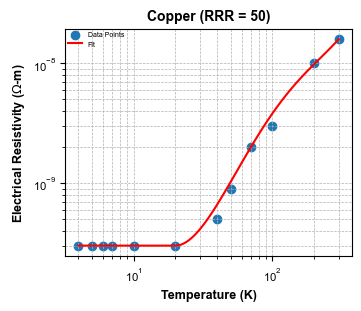

In [9]:
# Plot data points

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)

ax.scatter(t_data, rho_data, label='Data Points')
ax.loglog(x_vals, y_vals, color='red', label='Fit')
ax.set_title("Copper (RRR = 50)", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel(r'Electrical Resistivity ($\Omega$-m)', fontproperties=axis_label_font)
for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)
    
ax.legend(prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.savefig(f"./cu_electrical_resistivity.png",dpi=600)
plt.show()

In [10]:
# Assuming AWG30 wire
cable_diam = 0.2546E-3 # m (AWG30)
cable_area = np.pi * (cable_diam/2)**2

print("Resistance for AWG30 Copper (RRR=50)")
for temp_stage in TEMP_STAGES[1:3]:
    # get cable length
    cable_length = flange_separation[temp_stage]*1E-2 # cm to m
    
    # get operating temperatures
    current_temp_stage_idx = TEMP_STAGES.index(temp_stage)
    if current_temp_stage_idx > 0:
        prev_temp_stage = TEMP_STAGES[current_temp_stage_idx - 1]
    T_lo = operating_temp[temp_stage]
    T_hi = operating_temp[prev_temp_stage]

    # get_resistance() requires cable_length in meters
    resistance = get_resistance(cu_electrical_resistivity, cable_length, cable_area, T_lo, T_hi)
    
    print(f"{temp_stage}:\t {resistance:.2e} ohms")

Resistance for AWG30 Copper (RRR=50)
50K:	 4.84e-02 ohms
4K:	 2.31e-03 ohms
